In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# 1. Load CSV
df = pd.read_csv('Superstore.csv', encoding='latin1')

# 2. Convert Date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

# 3. Validation Output
print("Step 1 Complete: Data loaded successfully!")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
print(f"Date Range: {df['Order Date'].min().strftime('%Y-%m-%d')} to {df['Order Date'].max().strftime('%Y-%m-%d')}")
df[['Order ID', 'Order Date', 'Customer ID', 'Customer Name', 'Sales', 'Profit']].head(3)

Step 1 Complete: Data loaded successfully!
Total Rows: 9994, Total Columns: 21
Date Range: 2011-01-04 to 2014-12-31


,Order ID,Order Date,Customer ID,Customer Name,Sales,Profit
0,CA-2013-152156,2013-11-09,CG-12520,Claire Gute,261.96,41.9136
1,CA-2013-152156,2013-11-09,CG-12520,Claire Gute,731.94,219.5820
2,CA-2013-138688,2013-06-13,DV-13045,Darrin Van Huff,14.62,6.8714


In [3]:
# 1. Reference date: data ki aakhri date se 1 din aage
ref_date = df['Order Date'].max() + pd.Timedelta(days=1)

# 2. RFM Aggregation
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (ref_date - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
}).rename(columns={
    'Order Date': 'Recency',
    'Order ID': 'Frequency',
    'Sales': 'Monetary'
})

# 3. Customer Info merge karein
customer_meta = df[['Customer ID', 'Customer Name', 'Segment']].drop_duplicates(subset=['Customer ID'])
rfm = rfm.merge(customer_meta, on='Customer ID', how='left')

# 4. Quartile Scoring (1 se 4)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Total RFM Score
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# 5. Customer Segments assign karein
def assign_group(score):
    if score >= 10:
        return 'Champions / Loyal'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Customer_Group'] = rfm['RFM_Score'].apply(assign_group)

# 6. Summary Table
summary_rfm = rfm.groupby('Customer_Group').agg(
    Customer_Count=('Customer ID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Recency_Days=('Recency', 'mean')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

print("Step 2 Complete: RFM Segment Table Ready!")
summary_rfm

Step 2 Complete: RFM Segment Table Ready!


,Customer_Group,Customer_Count,Total_Revenue,Avg_Recency_Days
3,Potential Loyalists,309,1.022336e+06,103.679612
1,Champions / Loyal,193,9.215973e+05,36.782383
0,At Risk,178,2.623638e+05,177.488764
2,Lost Customers,113,9.090358e+04,411.336283


/tmp/ipykernel_867/315398801.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_867/315398801.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


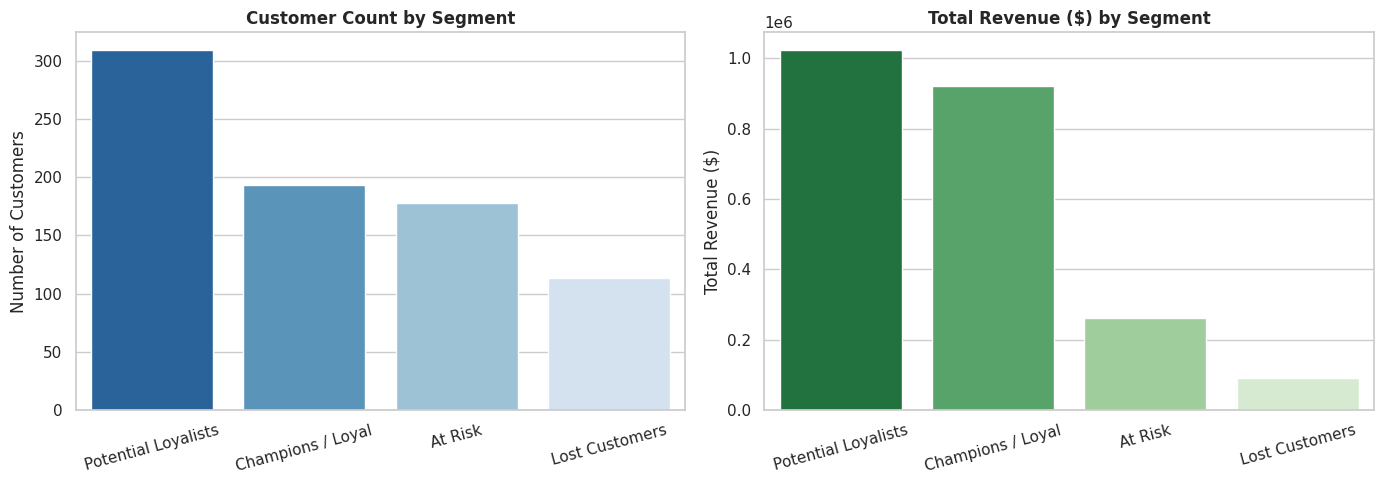

Step 3 Complete: RFM Segment Charts Generated!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Customer Count Distribution
sns.barplot(
    data=summary_rfm,
    x='Customer_Group',
    y='Customer_Count',
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Customer Count by Segment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Total Revenue Contribution
sns.barplot(
    data=summary_rfm,
    x='Customer_Group',
    y='Total_Revenue',
    palette='Greens_r',
    ax=axes[1]
)
axes[1].set_title('Total Revenue ($) by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print("Step 3 Complete: RFM Segment Charts Generated!")

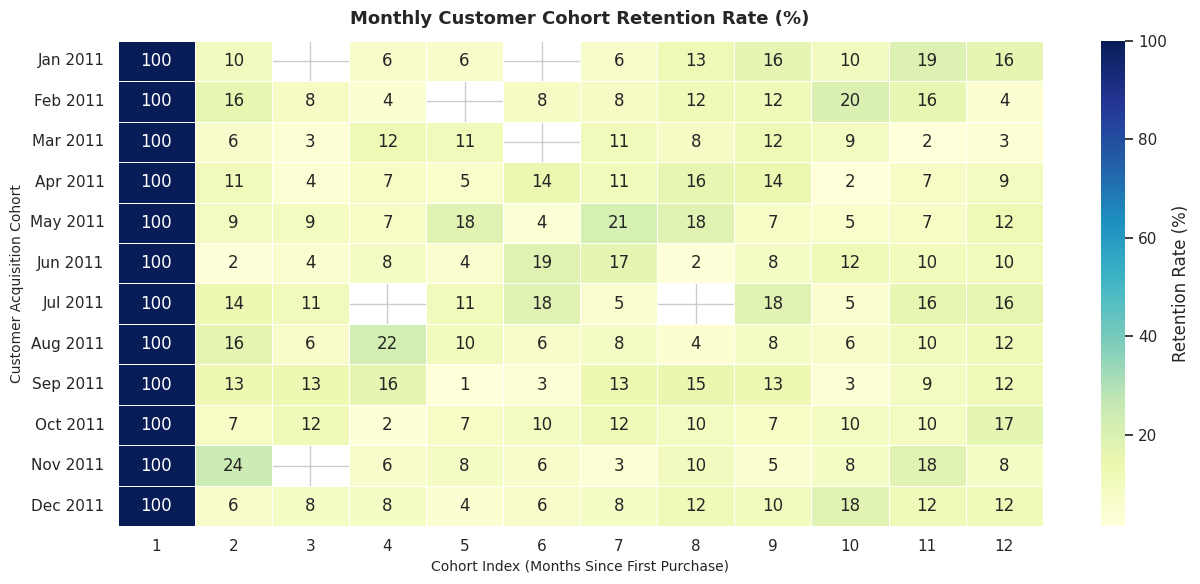

Step 4 Complete: Cohort Retention Heatmap Ready!


In [5]:
# 1. First order month extract karein
def get_month(x):
    return pd.to_datetime(x.strftime('%Y-%m-01'))

df['OrderMonth'] = df['Order Date'].apply(get_month)
df['CohortMonth'] = df.groupby('Customer ID')['OrderMonth'].transform('min')

# 2. Cohort Index (Kitne mahine baad order kiya)
order_year = df['OrderMonth'].dt.year
order_month = df['OrderMonth'].dt.month
cohort_year = df['CohortMonth'].dt.year
cohort_month = df['CohortMonth'].dt.month

df['CohortIndex'] = (order_year - cohort_year) * 12 + (order_month - cohort_month) + 1

# 3. Retention matrix calculate karein
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

# Top 12 initial cohorts for clear presentation
retention_12m = retention.iloc[:12, :12].copy()
retention_12m.index = retention_12m.index.strftime('%b %Y')

# 4. Plot Heatmap
plt.figure(figsize=(13, 6))
sns.heatmap(
    retention_12m,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5
)
plt.title('Monthly Customer Cohort Retention Rate (%)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Cohort Index (Months Since First Purchase)', fontsize=10)
plt.ylabel('Customer Acquisition Cohort', fontsize=10)
plt.tight_layout()
plt.show()

print("Step 4 Complete: Cohort Retention Heatmap Ready!")

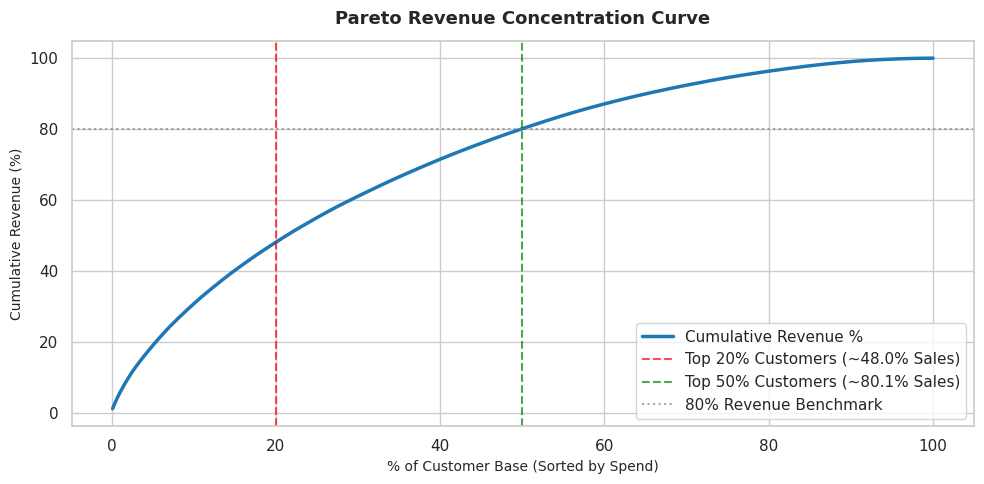

--- Executive Insights ---
1. Top 20% Customers (158 users) drive 47.96% of total sales.
2. Top 50% Customers (396 users) generate 80.06% of total revenue.


In [6]:
# 1. Customer Revenue Aggregation
customer_spend = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False).reset_index()

total_customers = len(customer_spend)
total_revenue = customer_spend['Sales'].sum()

# 2. Cumulative Percentages
customer_spend['Cumulative_Sales'] = customer_spend['Sales'].cumsum()
customer_spend['Cumulative_Revenue_Pct'] = (customer_spend['Cumulative_Sales'] / total_revenue) * 100
customer_spend['Customer_Rank_Pct'] = (np.arange(1, total_customers + 1) / total_customers) * 100

top_20_pct_rev = customer_spend[customer_spend['Customer_Rank_Pct'] <= 20]['Cumulative_Revenue_Pct'].max()
top_50_pct_rev = customer_spend[customer_spend['Customer_Rank_Pct'] <= 50]['Cumulative_Revenue_Pct'].max()

# 3. Plot Pareto Curve
plt.figure(figsize=(10, 5))
plt.plot(customer_spend['Customer_Rank_Pct'], customer_spend['Cumulative_Revenue_Pct'], color='#1f77b4', lw=2.5, label='Cumulative Revenue %')
plt.axvline(20, color='red', linestyle='--', alpha=0.7, label=f'Top 20% Customers (~{top_20_pct_rev:.1f}% Sales)')
plt.axvline(50, color='green', linestyle='--', alpha=0.7, label=f'Top 50% Customers (~{top_50_pct_rev:.1f}% Sales)')
plt.axhline(80, color='grey', linestyle=':', alpha=0.7, label='80% Revenue Benchmark')

plt.title('Pareto Revenue Concentration Curve', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('% of Customer Base (Sorted by Spend)', fontsize=10)
plt.ylabel('Cumulative Revenue (%)', fontsize=10)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("--- Executive Insights ---")
print(f"1. Top 20% Customers (158 users) drive {top_20_pct_rev:.2f}% of total sales.")
print(f"2. Top 50% Customers (396 users) generate {top_50_pct_rev:.2f}% of total revenue.")

### 💡 Strategic Business Recommendations (Intermediate Milestone)
1. **VIP Loyalty & Retention (Champions & Potential Loyalists):**
   - Top 20% customers drive ~48% of total revenue. Implement dedicated account managers and exclusive tiered discounts to prevent churn.
2. **Re-engagement Campaign (At Risk Segment):**
   - 178 customers (spending ~$262k) haven't purchased recently. Trigger personalized email re-activation workflows with customized bundle offers.
3. **Cohort Drop-off Mitigation:**
   - Sharp retention decline after Month 1 highlights the need for an automated 30-day post-purchase follow-up and targeted replenishment reminders.